<a href="https://colab.research.google.com/github/nasia2612/sc-alzheimer-ml/blob/main/sc_alzheimer_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 TRAIN Dataset: scRNA-seq from Alzheimer's disease prefrontal cortex
 Shape: 20,000 cells × 16,679 columns (16,678 genes + 1 label column 'tag')

 Info
 -highly sparse (mostly zeros)
 -labels: 7 brain cell types

The original file had formatting issues (separator, decimal, quote characters) that were fixed in R before saving as .rds (R's native binary format).We load it in Python via pyreadr, which reads .rds files directly into.

---




In [1]:


!pip install pyreadr

# connect with google drive
from google.colab import drive
drive.mount('/content/drive')

#pyreadr reads rds
import pyreadr

result = pyreadr.read_r("/content/drive/MyDrive/Colab Notebooks/sc_alzheimer/sc_alz_train_set.rds")
df = result[None]   # extract the dataframe

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,AL627309.1,AL669831.5,NOC2L,KLHL17,AL645608.8,HES4,ISG15,AGRN,C1orf159,TNFRSF18,...,MT.ND5,MT.ND6,MT.CYB,AC011043.1,AL592183.1,AC007325.4,AC007325.2,AL354822.1,AC240274.1,tag
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Inhibitory neuron
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,1.0,0.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0,Oligodendrocyte precursor cell
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,2.0,0.0,0.0,0.0,0.0,Excitatory neuron
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,6.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,Inhibitory neuron
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Oligodendrocyte


In [2]:

# EXPLORE THE DATA
# basic info about the data
print(df.info())
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 16679 entries, AL627309.1 to tag
dtypes: float64(16678), object(1)
memory usage: 2.5+ GB
None
(20000, 16679)
         AL627309.1    AL669831.5         NOC2L        KLHL17    AL645608.8  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       0.034550      0.181200      0.162250      0.064750      0.004950   
std        0.193283      0.486085      0.454131      0.269372      0.089027   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000      0.000000   
max        3.000000      5.000000      5.000000      4.000000      6.000000   

               HES4         ISG15          AGRN     C1orf159      TNFRSF18  \
count  20000.000

Key findings:

-memory 2.5 (it uses a lot of memory so we need float32 conversion and gc.collect()
-25%,50% -> 0 for most genes  → confirms extreme sparsity (dropout effect in scRNA-seq)
-lets see the distribution of some genes

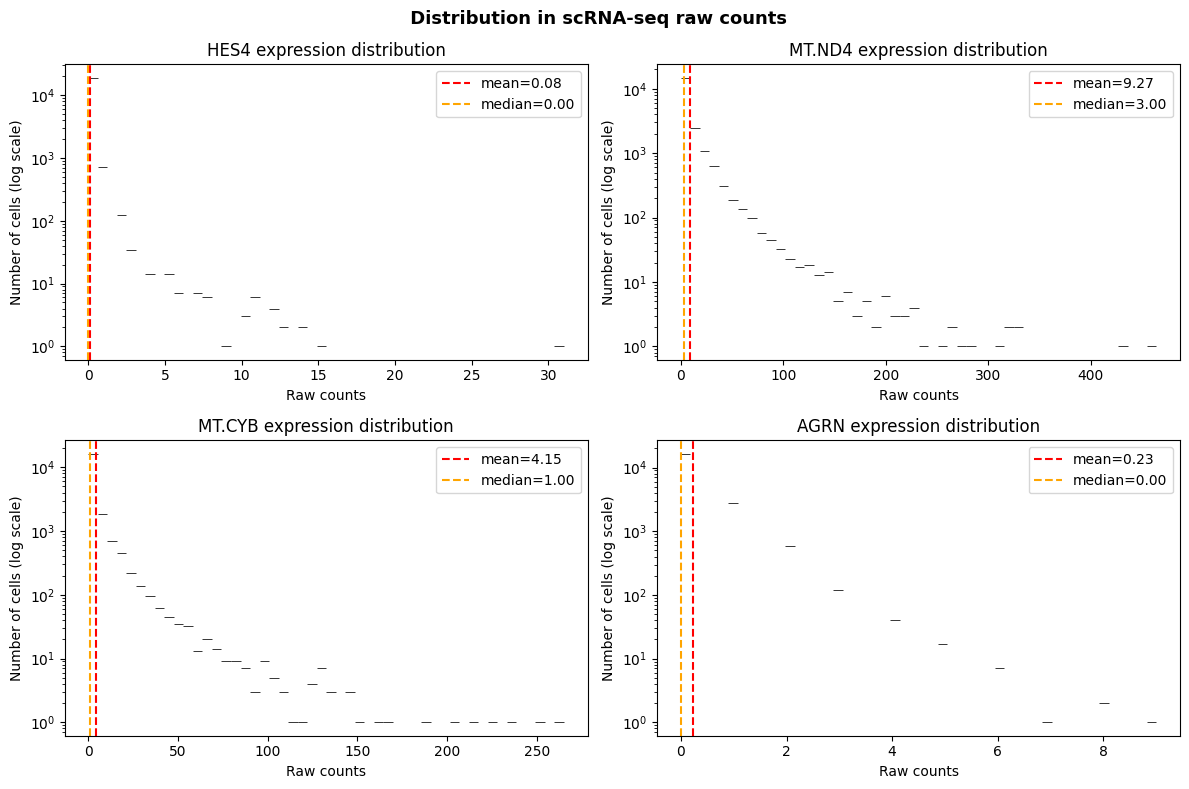

In [3]:

#plot the distribution of 4 genes

import seaborn as sns
import matplotlib.pyplot as plt

#i will pick these genes
genes_to_plot = ['HES4', 'MT.ND4', 'MT.CYB', 'AGRN']

#4x4 subplots
fig,axes=plt.subplots(2,2,figsize=(12,8))
axes=axes.flatten()

for i,gene in enumerate(genes_to_plot):
    sns.histplot(df[gene], bins=50, ax=axes[i], color='steelblue', log_scale=(False, True))

    axes[i].axvline(df[gene].mean(), color='red', linestyle='--', label=f'mean={df[gene].mean():.2f}')
    axes[i].axvline(df[gene].median(), color='orange', linestyle='--', label=f'median={df[gene].median():.2f}')

    axes[i].set_title(f'{gene} expression distribution')
    axes[i].set_xlabel('Raw counts')
    axes[i].set_ylabel('Number of cells (log scale)')
    axes[i].legend()

plt.suptitle(' Distribution in scRNA-seq raw counts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
%%capture stored_output
# Distribution of the cell types
print(df["tag"].value_counts())

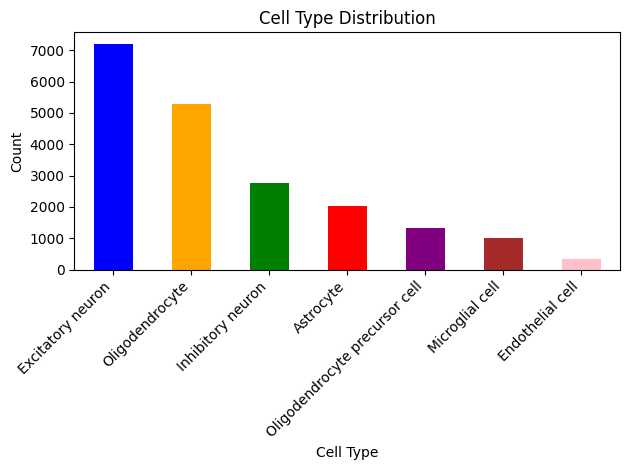

In [5]:

# do we have class imbalance?
import matplotlib.pyplot as plt

df["tag"].value_counts().plot(kind="bar", color=["blue","orange","green","red","purple","brown","pink"])
plt.title("Cell Type Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

we have class imbalance so we need to use balanced in class weight

 According to  (Mathys κ.ά., 2019) the distribution matches previous data from normal cortex.

In [6]:

# sparsity - how many zeros because of the nature of the data (dropout effect)
sparsity = (df.drop(columns=["tag"]) == 0).sum().sum()
total_values = df.shape[0] * (df.shape[1] - 1)
f" sparsity: {sparsity/total_values:.2%}"

' sparsity: 89.21%'

BIG SPARSITY

OUR APPROACH:
- log2(CPM+1) normalization compresses the dynamic range, making zeros less "dominant" relative to expressed genes
-MGECT feature selection removes uninformative genes (zero
-variance across cell types), reducing noise from dropout
- Random Forest with class_weight='balanced' handles remaining sparsity robustly via ensemble of decision trees

In [7]:

# all the cells have labels?
print((df["tag"] == "").sum())

0


#FINDING THE DUPLICATE CELLS

In [8]:
%%capture stored_output
# Check for duplicate rows in your raw data
#METHOD 1
duplicates = df.duplicated().sum()
print(f"Number of duplicate cells: {duplicates}")


In [9]:

#remove the duplicates
#METHOD 2
#removing cells with the sampe tag+total_countss (keep only first occurence)

df["total_counts"]=df.drop(columns=["tag"]).sum(axis=1)

before=len(df)

df=df[~df.duplicated(subset=["tag","total_counts"],keep="first")]
after=len(df)

df.drop(columns=["total_counts"],inplace=True)
print(f"Removed: {before - after} cells")
print(f"Remaining: {after} cells")




Removed: 5997 cells
Remaining: 14003 cells


/tmp/ipykernel_107698/2046532145.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["total_counts"],inplace=True)


In [10]:
%%capture stored_output
df.head()

## STEP 1: Separate X and y, then SPLIT first

Normalization (log2 CPM+1) is per-cell so technically safe before split,
but we move it AFTER split here to be methodologically cleaner.
StandardScaler MUST always be fit only on train — this prevents real data leakage.

In [11]:

import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import train_test_split

X = df.drop(columns=["tag"])
y = df["tag"]

gene_names = X.columns.tolist()

# Convert to float32 for memory efficiency
X_array = X.values.astype(np.float32)

del df, X
gc.collect()

print(f"X shape: {X_array.shape}")
print(f"y shape: {y.shape}")

X shape: (14003, 16678)
y shape: (14003,)


In [12]:

# STEP 2: Stratified train/val split on RAW counts (before normalization)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_array, y, test_size=0.2, random_state=42, stratify=y
)

del X_array
gc.collect()

print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_val_raw:   {X_val_raw.shape}")



X_train_raw: (11202, 16678)
X_val_raw:   (2801, 16678)


In [13]:

# STEP 3: Normalization log2(CPM+1) — applied separately to train and val
# Each cell is normalized by its OWN total counts (per-cell operation)
# No information crosses between train and val

def log2_cpm_normalize(X):
    total_counts = X.sum(axis=1, keepdims=True)
    X_cpm = X / total_counts * 1e6
    X_norm = np.log2(X_cpm + 1)
    return X_norm.astype(np.float32)

X_train_norm = log2_cpm_normalize(X_train_raw)
X_val_norm   = log2_cpm_normalize(X_val_raw)

del X_train_raw, X_val_raw
gc.collect()

print("Max after norm (train):", X_train_norm.max())
print("Max after norm (val):  ", X_val_norm.max())
print(f"Memory train MB: {X_train_norm.nbytes / 1e6:.1f}")

Max after norm (train): 16.903236
Max after norm (val):   17.281582
Memory train MB: 747.3


In [14]:

# STEP 4: MGECT — Housekeeping gene removal
# Fit ONLY on train to prevent leakage

X_train_df = pd.DataFrame(X_train_norm, columns=gene_names)
X_val_df   = pd.DataFrame(X_val_norm,   columns=gene_names)

del X_train_norm, X_val_norm
gc.collect()

# MGECT: compute median per cell type, then variance across cell types
mgect = X_train_df.copy()
mgect["tag"] = y_train.values
gene_variances = mgect.groupby("tag").median().var(axis=0)
del mgect
gc.collect()

# Genes with 0 variance across cell types = housekeeping genes (not informative)
housekeeping = gene_variances[gene_variances == 0].index
print(f"Housekeeping genes removed: {len(housekeeping)}")

X_train = X_train_df.drop(columns=housekeeping)
X_val   = X_val_df.drop(columns=housekeeping)

del X_train_df, X_val_df
gc.collect()

print(f"Genes remaining: {X_train.shape[1]}")
gene_names_filtered = X_train.columns.tolist()

Housekeeping genes removed: 14896
Genes remaining: 1782


In [15]:

# mitochondrial genes check
mt_genes = [g for g in gene_names_filtered if g.startswith("MT")]
print(f"MT genes in dataset: {len(mt_genes)}")

MT genes in dataset: 20


In [16]:

# STEP 5: StandardScaler — fit ONLY on train
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_val_scaled   = scaler.transform(X_val)          # only transform on val

del X_train, X_val
gc.collect()

print(f"Train: {X_train_scaled.shape}")
print(f"Val:   {X_val_scaled.shape}")

Train: (11202, 1782)
Val:   (2801, 1782)


We choose the method random forest classification because it can handle large datasets and high-dimensional data.Also,it reduces the risk of overfitting compared to a single decision tree and it is robust to noisy data

In [17]:

# STEP 6: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

# test on the validation set
y_pred = rf_model.predict(X_val_scaled)

test_accuracy = accuracy_score(y_val, y_pred)
print(f"Test accuracy: {test_accuracy:.2%}")

print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Test accuracy: 99.36%
                                precision    recall  f1-score   support

                     Astrocyte       1.00      1.00      1.00       307
              Endothelial cell       1.00      0.97      0.98        64
             Excitatory neuron       1.00      0.99      0.99      1081
             Inhibitory neuron       0.98      1.00      0.99       452
               Microglial cell       0.99      0.98      0.98       163
               Oligodendrocyte       0.99      1.00      1.00       500
Oligodendrocyte precursor cell       1.00      1.00      1.00       234

                      accuracy                           0.99      2801
                     macro avg       0.99      0.99      0.99      2801
                  weighted avg       0.99      0.99      0.99      2801


Confusion Matrix:
[[ 307    0    0    0    0    0    0]
 [   0   62    1    0    0    1    0]
 [   0    0 1071    7    2    1    0]
 [   0    0    0  451    0    1    0]
 [   0    0 

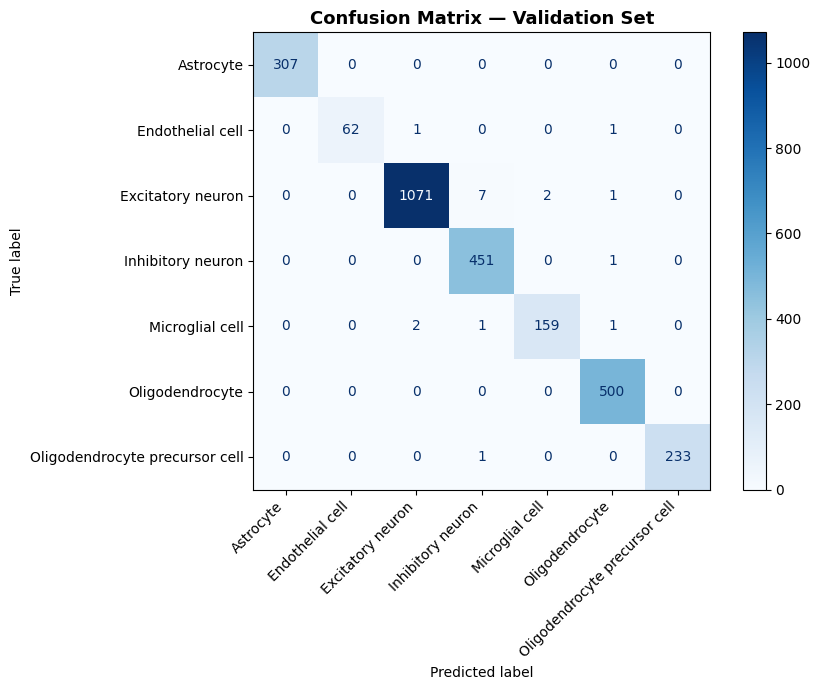

In [19]:
#Plotting the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

labels = sorted(y_val.unique()) #it sorts the cell types
cm=confusion_matrix(y_val,y_pred,labels=labels)

fig,ax=plt.subplots(figsize=(9,7))

disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)

disp.plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
#FIT UMAP to see the clustering
import umap
from sklearn.decomposition import PCA
# PCA πρώτα — από 1,590 → 30 dimensions
# Αφαιρεί noise και κάνει το UMAP πολύ πιο γρήγορο
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit on train
X_val_pca   = pca.transform(X_val_scaled)

reducer=umap.UMAP(n_components=2,random_state=42,n_neighbors=30,min_dist=0.3)
reducer.fit(X_train_scaled) #it learns from the train
#it projects it to validation set
X_val_umap=reducer.transform(X_val_scaled)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


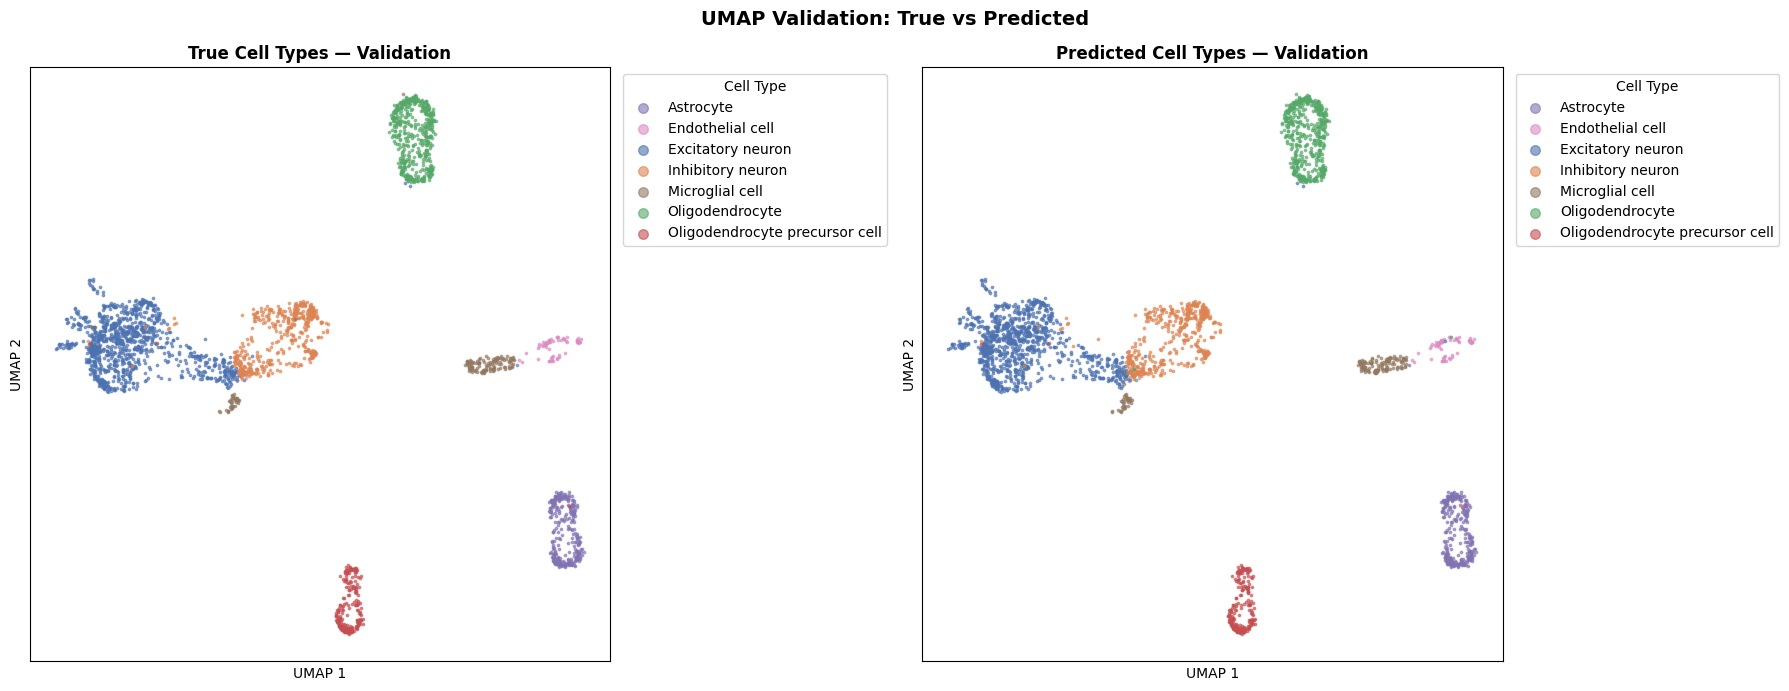

Transforming test set...
Done!


array([[-0.27855882,  3.6394384 ],
       [ 3.2141836 ,  6.212101  ],
       [ 5.50098   , -7.340673  ],
       ...,
       [-5.0589957 ,  5.5590944 ],
       [ 8.062869  , 17.476664  ],
       [ 8.811703  , 13.6028385 ]], dtype=float32)

In [31]:
#plotting the UMAP

cell_type_colors = {
    'Excitatory neuron': '#4C72B0',
    'Inhibitory neuron': '#DD8452',
    'Oligodendrocyte': '#55A868',
    'Oligodendrocyte precursor cell': '#C44E52',
    'Astrocyte': '#8172B2',
    'Microglial cell': '#937860',
    'Endothelial cell': '#DA8BC3'
}

fig,axes=plt.subplots(1,2,figsize=(18,7))

# --- Plot αριστερά: TRUE labels ---
for ct in sorted(y_val.unique()):
    mask = np.array(y_val) == ct          # boolean mask: ποια κελιά είναι αυτού του τύπου
    axes[0].scatter(
        X_val_umap[mask, 0],              # UMAP διάσταση 1 (x άξονας)
        X_val_umap[mask, 1],              # UMAP διάσταση 2 (y άξονας)
        c=cell_type_colors.get(ct, '#999'),
        label=ct, s=3, alpha=0.6
    )
axes[0].set_title('True Cell Types — Validation', fontweight='bold')
axes[0].legend(markerscale=4, title='Cell Type',
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].set_xticks([]); axes[0].set_yticks([])

# --- Plot δεξιά: PREDICTED labels ---
y_val_pred = rf_model.predict(X_val_scaled)   # predictions στο validation
for ct in sorted(set(y_val_pred)):
    mask = y_val_pred == ct
    axes[1].scatter(
        X_val_umap[mask, 0],
        X_val_umap[mask, 1],
        c=cell_type_colors.get(ct, '#999'),
        label=ct, s=3, alpha=0.6
    )
axes[1].set_title('Predicted Cell Types — Validation', fontweight='bold')
axes[1].legend(markerscale=4, title='Cell Type',
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle('UMAP Validation: True vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# Transform test — χρησιμοποιεί τον ίδιο reducer που fit-άρε στο train
print("Transforming test set...")
X_test_umap = reducer.transform(X_val_scaled)
print("Done!")


reducer.transform(X_val_scaled)




In [29]:

#FEATURE IMPORTANCE
# Create a series to map gene names to their importance scores
importances = pd.Series(rf_model.feature_importances_, index=gene_names_filtered)

# Sort and look at the top 10
top_10_genes = importances.sort_values(ascending=False).head(10)
print("Top 10 Most Important Genes:")
print(top_10_genes)

Top 10 Most Important Genes:
GPM6A      0.014776
FGF14      0.014535
ERBB4      0.012860
PCDH15     0.012666
CTNNA3     0.012365
PLXDC2     0.012303
SLC44A1    0.011896
ADGRV1     0.011104
CSMD1      0.010734
FLT1       0.010605
dtype: float64


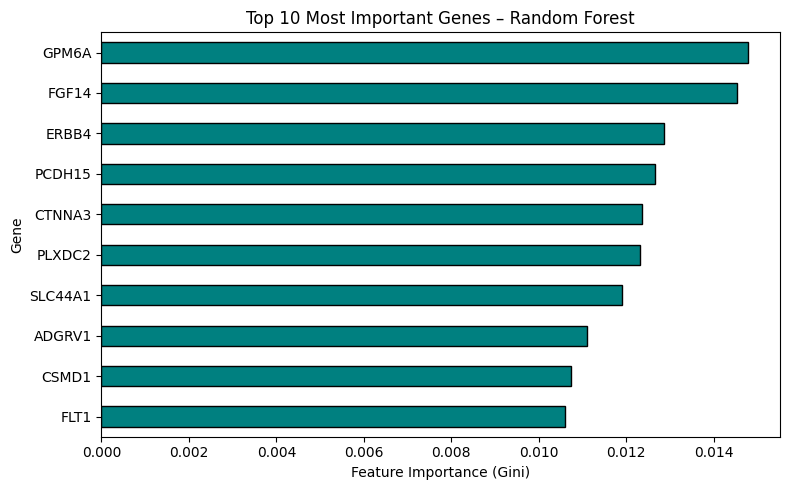

In [30]:

#VISUALISATION OF THE TOP TEN IMPORTANT GENES
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
top_10_genes.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')

ax.set_xlabel('Feature Importance (Gini)')
ax.set_ylabel('Gene')
ax.set_title('Top 10 Most Important Genes – Random Forest')
plt.tight_layout()
plt.show()

In [32]:

#tuning the hypermeters
import joblib
import os
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

CACHE_FILE = "/content/drive/MyDrive/Colab Notebooks/sc_alzheimer/cache/grid_search.pkl"

param_grid = {
    'n_estimators': [10, 100, 200, 300],
    'max_depth': [None, 3, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

if os.path.exists(CACHE_FILE):
    grid_search = joblib.load(CACHE_FILE)
    print("Loaded from cache!")
else:
    rf_model_tune = RandomForestClassifier(random_state=42, class_weight='balanced')
    grid_search = RandomizedSearchCV(
        rf_model_tune, param_grid,
        n_iter=10, cv=3,
        scoring='f1_weighted',
        n_jobs=-1, verbose=2, random_state=42
    )
    grid_search.fit(X_train_scaled, y_train)
    joblib.dump(grid_search, CACHE_FILE)
    print("Trained and saved!")

print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Trained and saved!
Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best F1: 0.9930840422834403


In [34]:

from sklearn.inspection import permutation_importance

# This takes longer but is much more robust against technical artifacts
result = permutation_importance(grid_search.best_estimator_, X_val_scaled, y_val, n_repeats=2, random_state=42, n_jobs=-1, max_samples=0.3)
perm_importances = pd.Series(result.importances_mean, index=gene_names_filtered)
print(perm_importances.sort_values(ascending=False).head(10))

MT.CYB   -0.000117
HES4     -0.000117
ACAP3    -0.000117
GNB1     -0.000117
CHD5     -0.000117
CAMTA1   -0.000117
TTC3     -0.000117
RUNX1    -0.000117
ITSN1    -0.000117
OLIG1    -0.000117
dtype: float64


In [35]:

#Final train set (validation+train)

X_full=np.vstack([X_train_scaled,X_val_scaled])
y_full=pd.concat([y_train,y_val])

final_rf = RandomForestClassifier(
    **grid_search.best_params_,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
final_rf.fit(X_full, y_full)
print("final model trained on full dataset with best params")

final model trained on full dataset with best params


In [36]:

#LOAD TEST SET
!pip install pyreadr
import pyreadr
from google.colab import drive
drive.mount('/content/drive')

#Read the test set
result_test=pyreadr.read_r("/content/drive/MyDrive/Colab Notebooks/sc_alzheimer/sc_alz_test_set.rds")
df_test=result_test[None]

del result_test
gc.collect()




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


102549

In [37]:

df_test.tail()

,AL627309.1,AL669831.5,NOC2L,KLHL17,AL645608.8,HES4,ISG15,AGRN,C1orf159,TNFRSF18,...,MT.ND4,MT.ND5,MT.ND6,MT.CYB,AC011043.1,AL592183.1,AC007325.4,AC007325.2,AL354822.1,AC240274.1
4995,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,2.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:

#Normalization
#keeping the gene names
gene_names_test = df_test.columns.tolist()

#convert it to float 32 to save memory
X_test_array=df_test.values.astype(np.float32)

del df_test
gc.collect()


X_test_norm=log2_cpm_normalize(X_test_array)

del X_test_array
gc.collect()



0

In [39]:

#Remove same housekeeping genes

X_test_df=pd.DataFrame(X_test_norm,columns=gene_names_test)

del X_test_norm
gc.collect()

X_test=X_test_df.drop(columns=housekeeping)

del X_test_df
gc.collect()

print(f"Genes remaining: {X_test.shape[1]}")
gene_names_filtered = X_test.columns.tolist()




Genes remaining: 1782


In [40]:

#Scaling

X_test_scaled=scaler.transform(X_test)

del X_test
gc.collect()

print(f"Test: {X_test_scaled.shape}")

Test: (5000, 1782)


In [43]:

#Testing the data
y_pred=final_rf.predict(X_test_scaled)

#save predictions as a csv

predictions_df=pd.DataFrame({'cell_index':range(len(y_pred)),
                             'predicted_label':y_pred})


predictions_df.to_csv('/content/drive/MyDrive/datathon/predictions.csv', index=False)

print(f"Saved {len(y_pred)} predictions")
print(predictions_df['predicted_label'].value_counts())


Saved 5000 predictions
predicted_label
Excitatory neuron                 1773
Oligodendrocyte                   1304
Inhibitory neuron                  721
Astrocyte                          552
Oligodendrocyte precursor cell     324
Microglial cell                    256
Endothelial cell                    70
Name: count, dtype: int64


Transforming test set...
Done!


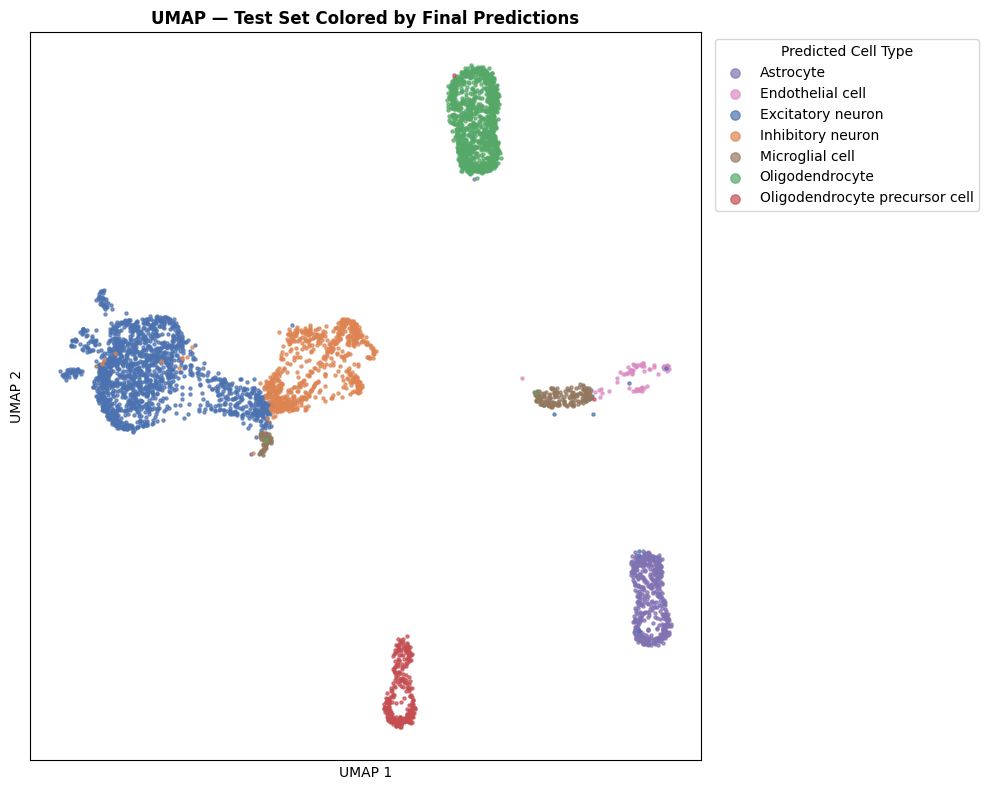

In [44]:
# Transform test — χρησιμοποιεί τον ίδιο reducer που fit-άρε στο train
print("Transforming test set...")
X_test_pca  = pca.transform(X_test_scaled)
X_test_umap = reducer.transform(X_test_scaled)
print("Done!")


# UMAP test colored by final predictions
fig, ax = plt.subplots(figsize=(10, 8))
y_pred_arr = np.array(y_pred)     # μετατρέπει τα predictions σε numpy array

for ct in sorted(set(y_pred_arr)):
    mask = y_pred_arr == ct
    ax.scatter(
        X_test_umap[mask, 0],
        X_test_umap[mask, 1],
        c=cell_type_colors.get(ct, '#999'),
        label=ct, s=5, alpha=0.7
    )

ax.legend(markerscale=3, title='Predicted Cell Type',
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('UMAP — Test Set Colored by Final Predictions', fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()
